In [26]:
#IMPORTING PACKAGES

import numpy as np
import cv2
import matplotlib
import PIL
import torch
import torchvision
import flask
import sklearn

True
True
True
Parasitized:  13779
Uninfected:  13779
INFECTED CELL
size:  (112, 115)
mode:  RGB
shape:  (115, 112, 3)


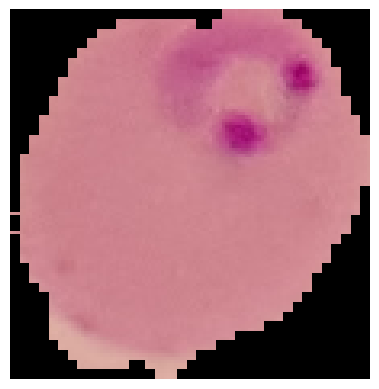

UNINFECTED CELL
size:  (115, 127)
mode:  RGB
shape:  (127, 115, 3)


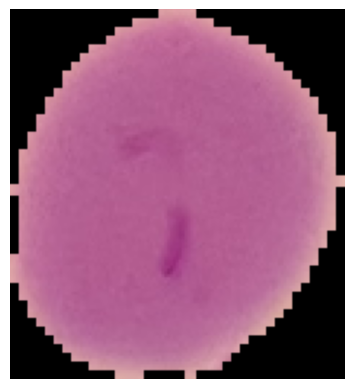

In [2]:
#INSPECTING THE DATASET

from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image

dataset_path = Path("dataset")
parasitized_path = dataset_path /  "Parasitized"
uninfected_path = dataset_path / "Uninfected"

print(dataset_path.exists())
print(parasitized_path.exists())
print(uninfected_path.exists())

#finding all images
parasitized_images = list(parasitized_path.glob("*.png"))
uninfected_images = list(uninfected_path.glob("*.png"))

print("Parasitized: ", len(parasitized_images))
print("Uninfected: ", len(uninfected_images))

#inspecting an infected cell image
print("INFECTED CELL")
image1 = Image.open(parasitized_images[0])
image1_nparray = np.array(image1)

print("size: ", image1.size)
print("mode: ", image1.mode)
print("shape: ", image1_nparray.shape)

plt.imshow(image1)
plt.axis("off")
plt.show()

#inspecting an uninfected cell image
print("UNINFECTED CELL")
image2 = Image.open(uninfected_images[0])
image2_nparray = np.array(image2)

print("size: ", image2.size)
print("mode: ", image2.mode)
print("shape: ", image2_nparray.shape)

plt.imshow(image2)
plt.axis("off")
plt.show()

In [3]:
import torch
import random
from torchvision import datasets, transforms 
from torch.utils.data import DataLoader, random_split

dataset = datasets.ImageFolder("dataset")
print(dataset.class_to_idx)

{'Parasitized': 0, 'Uninfected': 1}


In [4]:
print("Total Images:", len(dataset))
print("Classes: ", dataset.classes)

Total Images: 27558
Classes:  ['Parasitized', 'Uninfected']


In [5]:
dataset_path = Path("dataset")
parasitized_images = list((dataset_path / "Parasitized").glob("*.png"))
uninfected_images = list((dataset_path / "Uninfected").glob("*.png"))

print("Parasitized:", len(parasitized_images))
print("Uninfected:", len(uninfected_images))

parasitized_data = [(path, 0) for path in parasitized_images]
uninfected_data = [(path, 1) for path in uninfected_images]

all_data = parasitized_data + uninfected_data
print("Total:", len(all_data))

Parasitized: 13779
Uninfected: 13779
Total: 27558


In [6]:
random.seed(42)
random.shuffle(all_data)

In [7]:
total_size = len(all_data)

train_size = int(0.70*total_size)
val_size = int(0.15*total_size)
test_size = total_size - train_size - val_size

print("total size: ", total_size)
print("train_size: ", train_size)
print("val_size: ", val_size)
print("test_size: ", test_size)

total size:  27558
train_size:  19290
val_size:  4133
test_size:  4135


In [8]:
#SPLITTING DATA

train_data = all_data[:train_size]
val_data = all_data[train_size:train_size+val_size]
test_data = all_data[train_size+val_size:]

In [9]:
#CHECKING FOR OVERLAPS

train_paths = set(path for path, label in train_data)
val_paths = set(path for path, label in val_data)
test_paths = set(path for path, label in test_data)

print("Train/Val overlap:", len(train_paths & val_paths))
print("Train/Test overlap:", len(train_paths & test_paths))
print("Val/Test overlap:", len(val_paths & test_paths))

Train/Val overlap: 0
Train/Test overlap: 0
Val/Test overlap: 0


In [10]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

class MalariaDataset(Dataset):

    def __init__(self, data, transform=None):
        self.data = data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):

        image_path, label = self.data[index]

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

stats_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

stats_dataset = MalariaDataset(
    train_data,
    transform=stats_transform
)

stats_loader = DataLoader(
    stats_dataset,
    batch_size=32,
    shuffle=False
)

mean = torch.zeros(3)
std = torch.zeros(3)

total_images = 0

for images, _ in stats_loader:

    batch_size = images.size(0)
    
    images = images.view(batch_size, 3, -1)

    mean += images.mean(dim=2).sum(dim=0)

    std += images.std(dim=2).sum(dim=0)

    total_images += batch_size
    
mean /= total_images
std /= total_images

print("Mean:", mean)
print("Std:", std)

mean_values = mean.tolist()
std_values = std.tolist()

print("Mean values:", mean_values)
print("Std values:", std_values)

train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),

    transforms.Normalize(
        mean=mean_values,
        std=std_values
    )
])

test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),

    transforms.Normalize(
        mean=mean_values,
        std=std_values
    )
])

train_dataset = MalariaDataset(
    train_data,
    transform=train_transform
)

val_dataset = MalariaDataset(
    val_data,
    transform=test_transform
)

test_dataset = MalariaDataset(
    test_data,
    transform=test_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

Mean: tensor([0.5298, 0.4241, 0.4531])
Std: tensor([0.3273, 0.2638, 0.2780])
Mean values: [0.5297750234603882, 0.4240841567516327, 0.4531458020210266]
Std values: [0.32734930515289307, 0.2637665569782257, 0.27798572182655334]
Images shape: torch.Size([32, 3, 128, 128])
Labels shape: torch.Size([32])


In [11]:
import torch
import torch.nn as nn
from torchvision import models

model = models.resnet18(weights="DEFAULT")
model.fc = nn.Linear(
    model.fc.in_features,
    2
)
print(model.fc)

Linear(in_features=512, out_features=2, bias=True)


In [12]:
#loss function
criterion = nn.CrossEntropyLoss()

#optimiser
optimizer = torch.optim.Adam(
    #weights
    model.parameters(),
    #learning rate
    lr=0.001
)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

model = model.to(device)

#training loop
num_epochs = 5

for epoch in range(num_epochs):

    #switching to training behaviour
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        # Remove old gradients
        #gradients tell optimizer how the weights should change
        optimizer.zero_grad()

        # Make predictions
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Calculate gradients
        loss.backward()

        # Update weights
        optimizer.step()

        # Track loss
        running_loss += loss.item()

        # Get predicted class
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_accuracy = 100 * correct / total

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Accuracy: {train_accuracy:.2f}%"
    )

    #validation
    val_loss = 0.0

    val_correct = 0

    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)

            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)

            val_correct += (predicted == labels).sum().item()

    val_loss = val_loss / len(val_loader)

    val_accuracy = 100 * val_correct / val_total

    print(

        f"Validation Loss: {val_loss:.4f} "

        f"Validation Accuracy: {val_accuracy:.2f}%"

    )

Epoch [1/5] Train Loss: 0.1547 Train Accuracy: 94.95%
Validation Loss: 0.1475 Validation Accuracy: 95.38%
Epoch [2/5] Train Loss: 0.1265 Train Accuracy: 95.76%
Validation Loss: 0.1451 Validation Accuracy: 95.57%
Epoch [3/5] Train Loss: 0.1155 Train Accuracy: 96.04%
Validation Loss: 0.1410 Validation Accuracy: 96.10%
Epoch [4/5] Train Loss: 0.1123 Train Accuracy: 96.12%
Validation Loss: 0.1306 Validation Accuracy: 96.35%
Epoch [5/5] Train Loss: 0.1075 Train Accuracy: 96.30%
Validation Loss: 0.1413 Validation Accuracy: 95.98%


In [13]:
#switching to evalvuation mode
model.eval()

test_correct = 0
test_total = 0

all_predictions = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_accuracy = 100 * test_correct / test_total

print(f"Test Accuracy: {test_accuracy:.2f}%")

#confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_predictions)
print(cm)

#precision
from sklearn.metrics import classification_report

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=["Parasitized", "Uninfected"]
    )
)

Test Accuracy: 95.74%
[[1980   62]
 [ 114 1979]]
              precision    recall  f1-score   support

 Parasitized       0.95      0.97      0.96      2042
  Uninfected       0.97      0.95      0.96      2093

    accuracy                           0.96      4135
   macro avg       0.96      0.96      0.96      4135
weighted avg       0.96      0.96      0.96      4135



In [25]:
from PIL import Image
import torch

def predict_image(image_path):

    # Open image
    image = Image.open(image_path).convert("RGB")

    # Apply the same preprocessing used for test images
    image = test_transform(image)

    # Add batch dimension
    image = image.unsqueeze(0)

    # Move image to the same device as the model
    image = image.to(device)

    # Make prediction
    model.eval()

    with torch.no_grad():
        outputs = model(image)

        probabilities = torch.softmax(outputs, dim=1)

        confidence, predicted_class = torch.max(probabilities, 1)

    # Convert class number to class name
    class_names = ["Parasitized", "Uninfected"]

    prediction = class_names[predicted_class.item()]
    confidence = confidence.item() * 100

    print("Prediction:", prediction)
    print("Confidence:", f"{confidence:.2f}%")

    return prediction, confidence

image_path, actual_label = test_data[1287]

print("Actual label:", actual_label)
predict_image(image_path)

Actual label: 1
Prediction: Uninfected
Confidence: 99.11%


('Uninfected', 99.10964965820312)

In [27]:
torch.save(model.state_dict(), "malaria_resnet18.pth")